<a href="https://colab.research.google.com/github/felipemingo321/actuarial-portfolio/blob/main/Gesti%C3%B3n_de_Datos_y_Consultas_SQL_para_An%C3%A1lisis_de_Riesgo_en_Seguros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Proyecto Actuarial: Gestión de Datos y Consultas SQL para Análisis de Riesgo en Seguros

#Autor: Felipe Mingo
#Fecha: Marzo 2026

#Descripción:
#En este proyecto se diseña una base de datos relacional que simula la operación de una compañía de seguros (pólizas, siniestros y pagos). Se generan datos sintéticos y se realizan consultas SQL para extraer indicadores clave de riesgo, como:

#- Siniestralidad por ramo (loss ratio)
#- Reservas IBNR (siniestros ocurridos no reportados)
#- Antigüedad de siniestros abiertos
#- Pólizas con mayor ratio de siniestralidad

#Se utiliza SQLite integrado con Python, y los resultados se visualizan con matplotlib y seaborn.

In [3]:
# Instalación de librerías necesarias
!pip install pandas matplotlib seaborn faker --quiet

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
from datetime import datetime, timedelta
import random

# Configuración de estilo y semillas para reproducibilidad
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
random.seed(42)
fake = Faker('es_ES')
Faker.seed(42)

In [5]:
# Conexión a base de datos SQLite en memoria
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()
print("✅ Base de datos creada en memoria.")

✅ Base de datos creada en memoria.


In [6]:
# Definición del esquema de tablas

In [7]:
# Tabla de pólizas
cursor.execute('''
CREATE TABLE polizas (
    id_poliza INTEGER PRIMARY KEY AUTOINCREMENT,
    ramo TEXT NOT NULL,
    prima REAL NOT NULL,
    fecha_inicio DATE NOT NULL,
    fecha_fin DATE NOT NULL,
    asegurado TEXT NOT NULL
)
''')

# Tabla de siniestros
cursor.execute('''
CREATE TABLE siniestros (
    id_siniestro INTEGER PRIMARY KEY AUTOINCREMENT,
    id_poliza INTEGER NOT NULL,
    fecha_ocurrencia DATE NOT NULL,
    fecha_reporte DATE NOT NULL,
    monto_estimado REAL,
    FOREIGN KEY (id_poliza) REFERENCES polizas(id_poliza)
)
''')

# Tabla de pagos
cursor.execute('''
CREATE TABLE pagos (
    id_pago INTEGER PRIMARY KEY AUTOINCREMENT,
    id_siniestro INTEGER NOT NULL,
    fecha_pago DATE NOT NULL,
    monto_pago REAL NOT NULL,
    FOREIGN KEY (id_siniestro) REFERENCES siniestros(id_siniestro)
)
''')

print("✅ Tablas creadas: polizas, siniestros, pagos.")

✅ Tablas creadas: polizas, siniestros, pagos.


In [8]:
# Generación de datos simulados

In [9]:
# Parámetros
num_polizas = 100
ramos = ['Auto', 'Hogar', 'Vida', 'Salud', 'Empresas']
fecha_min = datetime(2020, 1, 1)
fecha_max = datetime(2024, 12, 31)

# ---------- Pólizas ----------
polizas = []
for i in range(num_polizas):
    ramo = random.choice(ramos)
    prima = round(random.uniform(200, 2000), 2)
    inicio = fake.date_between(start_date=fecha_min, end_date=fecha_max)
    duracion_dias = random.randint(180, 730)
    fin = inicio + timedelta(days=duracion_dias)
    asegurado = fake.name()
    polizas.append([i+1, ramo, prima, inicio, fin, asegurado])

df_polizas = pd.DataFrame(polizas, columns=['id_poliza', 'ramo', 'prima', 'fecha_inicio', 'fecha_fin', 'asegurado'])
df_polizas.to_sql('polizas', conn, if_exists='append', index=False)
print(f"✅ {len(df_polizas)} pólizas insertadas.")

# ---------- Siniestros (aprox 1.5 por póliza) ----------
num_siniestros = int(num_polizas * 1.5)
siniestros = []
for i in range(1, num_siniestros+1):
    id_poliza = random.randint(1, num_polizas)
    poliza = df_polizas[df_polizas.id_poliza == id_poliza].iloc[0]
    inicio_pol = pd.to_datetime(poliza.fecha_inicio)
    fin_pol = pd.to_datetime(poliza.fecha_fin)
    ocurrencia = fake.date_between(start_date=inicio_pol, end_date=fin_pol)
    reporte = ocurrencia + timedelta(days=random.randint(0, 60))
    monto_estimado = round(random.uniform(500, 50000), 2)
    siniestros.append([i, id_poliza, ocurrencia, reporte, monto_estimado])

df_siniestros = pd.DataFrame(siniestros, columns=['id_siniestro', 'id_poliza', 'fecha_ocurrencia', 'fecha_reporte', 'monto_estimado'])
df_siniestros.to_sql('siniestros', conn, if_exists='append', index=False)
print(f"✅ {len(df_siniestros)} siniestros insertados.")

# ---------- Pagos (0 a 4 por siniestro) ----------
pagos = []
pago_id = 1
for _, siniestro in df_siniestros.iterrows():
    num_pagos = random.randint(0, 4)
    monto_restante = siniestro.monto_estimado
    for j in range(num_pagos):
        fecha_pago = pd.to_datetime(siniestro.fecha_reporte) + timedelta(days=random.randint(0, 180))
        if j == num_pagos - 1:
            monto_pago = round(monto_restante, 2)
        else:
            monto_pago = round(random.uniform(0.1, monto_restante * 0.7), 2)
            monto_restante -= monto_pago
        pagos.append([pago_id, siniestro.id_siniestro, fecha_pago, monto_pago])
        pago_id += 1

df_pagos = pd.DataFrame(pagos, columns=['id_pago', 'id_siniestro', 'fecha_pago', 'monto_pago'])
df_pagos.to_sql('pagos', conn, if_exists='append', index=False)
print(f"✅ {len(df_pagos)} pagos insertados.")

✅ 100 pólizas insertadas.
✅ 150 siniestros insertados.
✅ 300 pagos insertados.


In [10]:
# Verificación rápida
print("🔍 Primeras 5 pólizas:")
print(pd.read_sql_query("SELECT * FROM polizas LIMIT 5", conn))
print("\n🔍 Primeros 5 siniestros:")
print(pd.read_sql_query("SELECT * FROM siniestros LIMIT 5", conn))
print("\n🔍 Primeros 5 pagos:")
print(pd.read_sql_query("SELECT * FROM pagos LIMIT 5", conn))

🔍 Primeras 5 pólizas:
   id_poliza      ramo    prima fecha_inicio   fecha_fin  \
0          1      Auto   245.02   2023-03-13  2024-06-16   
1          2     Hogar   601.78   2021-02-11  2021-11-22   
2          3  Empresas   356.49   2020-02-28  2021-11-01   
3          4      Auto   253.63   2023-01-04  2024-02-11   
4          5     Hogar  1109.64   2022-03-31  2022-10-24   

                asegurado  
0  Raimundo Llopis Hierro  
1         Nilo Bonet Roca  
2  César Guerrero Vazquez  
3       Chita del Giménez  
4   Sandalio Agudo-Cuervo  

🔍 Primeros 5 siniestros:
   id_siniestro  id_poliza fecha_ocurrencia fecha_reporte  monto_estimado
0             1          2       2021-06-04    2021-07-16        40946.65
1             2         39       2024-08-03    2024-10-01        33337.74
2             3         18       2021-11-13    2021-11-29         6213.72
3             4         14       2022-06-07    2022-07-24        27884.57
4             5         35       2022-10-20    2022-1

In [11]:
# 📊 Indicador 1: Siniestralidad por ramo (Loss Ratio)

📈 Siniestralidad por ramo:
       ramo  prima_total  pagos_total  loss_ratio_pct
0     Hogar     51347.91    539206.44         1050.10
1      Vida     64296.30    563364.17          876.20
2  Empresas     74198.18    588954.69          793.76
3      Auto    107900.77    843929.30          782.13
4     Salud     47120.28    306311.42          650.06


/tmp/ipykernel_151/1759555066.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_loss_ratio, x='ramo', y='loss_ratio_pct', palette='Reds_r')


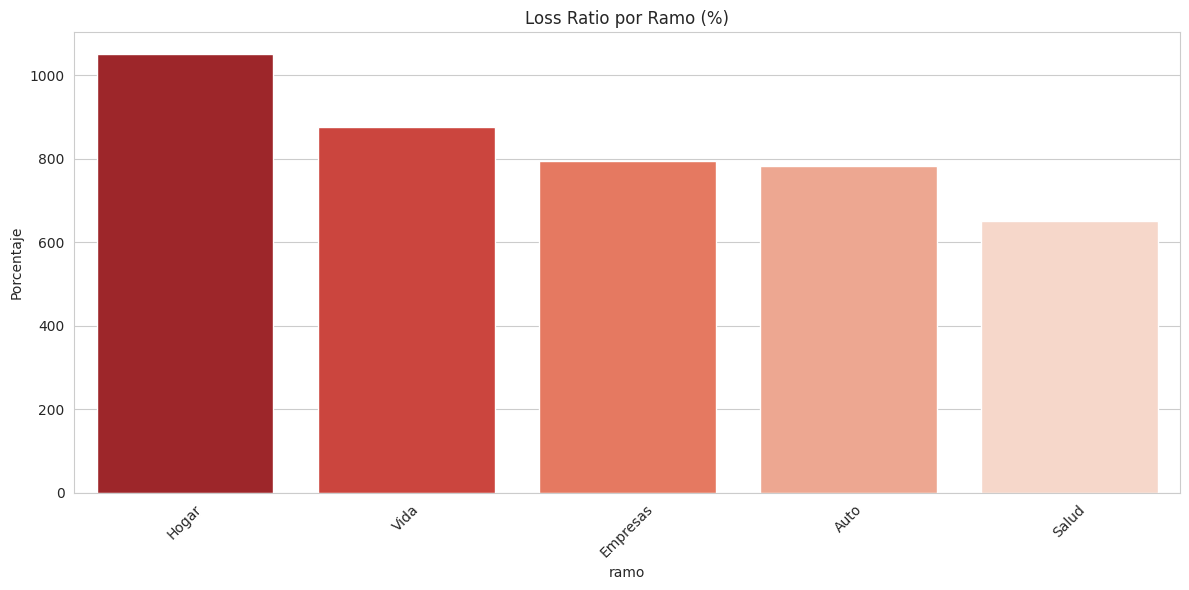

In [12]:
query1 = '''
SELECT
    p.ramo,
    SUM(p.prima) AS prima_total,
    COALESCE(SUM(pg.monto_pago), 0) AS pagos_total,
    ROUND(COALESCE(SUM(pg.monto_pago), 0) / SUM(p.prima) * 100, 2) AS loss_ratio_pct
FROM polizas p
LEFT JOIN siniestros s ON p.id_poliza = s.id_poliza
LEFT JOIN pagos pg ON s.id_siniestro = pg.id_siniestro
GROUP BY p.ramo
ORDER BY loss_ratio_pct DESC;
'''

df_loss_ratio = pd.read_sql_query(query1, conn)
print("📈 Siniestralidad por ramo:")
print(df_loss_ratio)

# Gráfico
plt.figure()
sns.barplot(data=df_loss_ratio, x='ramo', y='loss_ratio_pct', palette='Reds_r')
plt.title('Loss Ratio por Ramo (%)')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# 📊 Indicador 2: Reservas IBNR (siniestros ocurridos no reportados)

📅 Siniestros ocurridos antes del corte y estado de reporte:
  anio_ocurrencia  siniestros_ocurridos  siniestros_no_reportados  \
0            2020                     5                         0   
1            2021                    42                         0   
2            2022                    28                         0   
3            2023                    28                         0   
4            2024                    27                         1   

   pct_no_reportados  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                3.7  


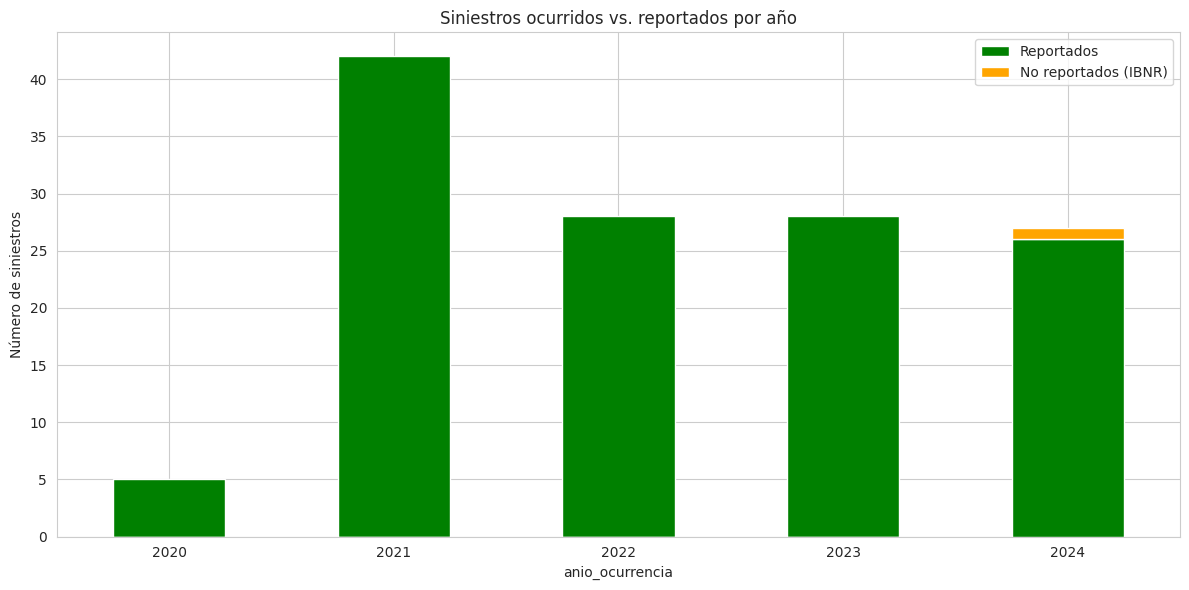

In [14]:
fecha_corte = '2025-01-01'

query2 = f'''
SELECT
    strftime('%Y', fecha_ocurrencia) AS anio_ocurrencia,
    COUNT(*) AS siniestros_ocurridos,
    SUM(CASE WHEN fecha_reporte > '{fecha_corte}' THEN 1 ELSE 0 END) AS siniestros_no_reportados,
    ROUND(100.0 * SUM(CASE WHEN fecha_reporte > '{fecha_corte}' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_no_reportados
FROM siniestros
WHERE fecha_ocurrencia <= '{fecha_corte}'
GROUP BY anio_ocurrencia
ORDER BY anio_ocurrencia;
'''

df_ibnr = pd.read_sql_query(query2, conn)
print("📅 Siniestros ocurridos antes del corte y estado de reporte:")
print(df_ibnr)

# Gráfico de barras apiladas
df_plot = df_ibnr.set_index('anio_ocurrencia')[['siniestros_ocurridos', 'siniestros_no_reportados']]
df_plot['siniestros_reportados'] = df_plot['siniestros_ocurridos'] - df_plot['siniestros_no_reportados']
df_plot[['siniestros_reportados', 'siniestros_no_reportados']].plot(kind='bar', stacked=True, color=['green', 'orange'])
plt.title('Siniestros ocurridos vs. reportados por año')
plt.ylabel('Número de siniestros')
plt.xticks(rotation=0)
plt.legend(['Reportados', 'No reportados (IBNR)'])
plt.tight_layout()
plt.show()

In [15]:
# 📊 Indicador 3: Antigüedad de siniestros con pagos pendientes

⏳ Siniestros abiertos más antiguos (top 10 por días desde ocurrencia):
   id_siniestro fecha_ocurrencia  monto_estimado  total_pagado  \
0            96       2020-03-30        44092.51      44092.51   
1           101       2020-10-29        11361.37      11361.37   
2            67       2020-12-07        42562.02          0.00   
3           138       2021-01-16        44632.96          0.00   
4            30       2021-02-01        10378.86          0.00   
5           131       2021-02-22        42589.52          0.00   
6            59       2021-03-23        22386.91      22386.91   
7            95       2021-03-26        47330.07          0.00   
8            23       2021-05-20         8543.84          0.00   
9           105       2021-06-12         6817.58          0.00   

   saldo_pendiente  dias_desde_ocurrencia  
0     7.275958e-12             2170.55994  
1     1.818989e-12             1957.55994  
2     4.256202e+04             1918.55994  
3     4.463296e+04        

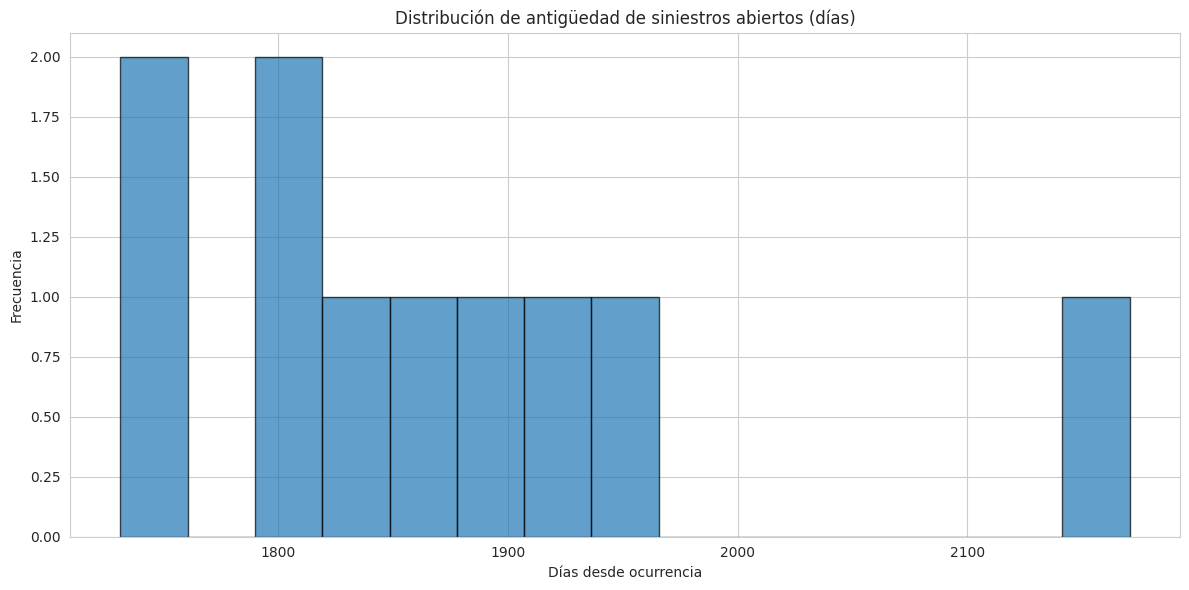

In [16]:
query3 = '''
SELECT
    s.id_siniestro,
    s.fecha_ocurrencia,
    s.monto_estimado,
    COALESCE(SUM(pg.monto_pago), 0) AS total_pagado,
    s.monto_estimado - COALESCE(SUM(pg.monto_pago), 0) AS saldo_pendiente,
    julianday('now') - julianday(s.fecha_ocurrencia) AS dias_desde_ocurrencia
FROM siniestros s
LEFT JOIN pagos pg ON s.id_siniestro = pg.id_siniestro
GROUP BY s.id_siniestro
HAVING saldo_pendiente > 0
ORDER BY dias_desde_ocurrencia DESC
LIMIT 10;
'''

df_antiguedad = pd.read_sql_query(query3, conn)
print("⏳ Siniestros abiertos más antiguos (top 10 por días desde ocurrencia):")
print(df_antiguedad)

# Histograma de antigüedad
plt.figure()
plt.hist(df_antiguedad['dias_desde_ocurrencia'], bins=15, edgecolor='black', alpha=0.7)
plt.title('Distribución de antigüedad de siniestros abiertos (días)')
plt.xlabel('Días desde ocurrencia')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [17]:
# 📊 Indicador 4: Pólizas con mayor ratio de siniestralidad

🔥 Top 10 pólizas con mayor ratio pago/prima:
   id_poliza      ramo                             asegurado   prima  \
0         23     Hogar                    Ruy Roca Bartolomé  494.12   
1          3  Empresas                César Guerrero Vazquez  356.49   
2          4      Auto                     Chita del Giménez  253.63   
3         35      Auto               Isabel Villar Sanmiguel  475.11   
4         87  Empresas                           Edu Arregui  322.33   
5         97      Vida  Eva María Araceli Gutierrez Menéndez  438.42   
6         41      Auto               Maricruz Suárez-Herrero  728.30   
7         52     Hogar                     Nadia del Cortina  431.10   
8         69      Auto                    Arturo Roda Lloret  924.72   
9         59      Vida                 Lourdes Molina-Julián  237.86   

   total_pagado  ratio_pago_prima  
0     170313.31            344.68  
1      79336.68            222.55  
2      41302.11            162.84  
3      73098.88   

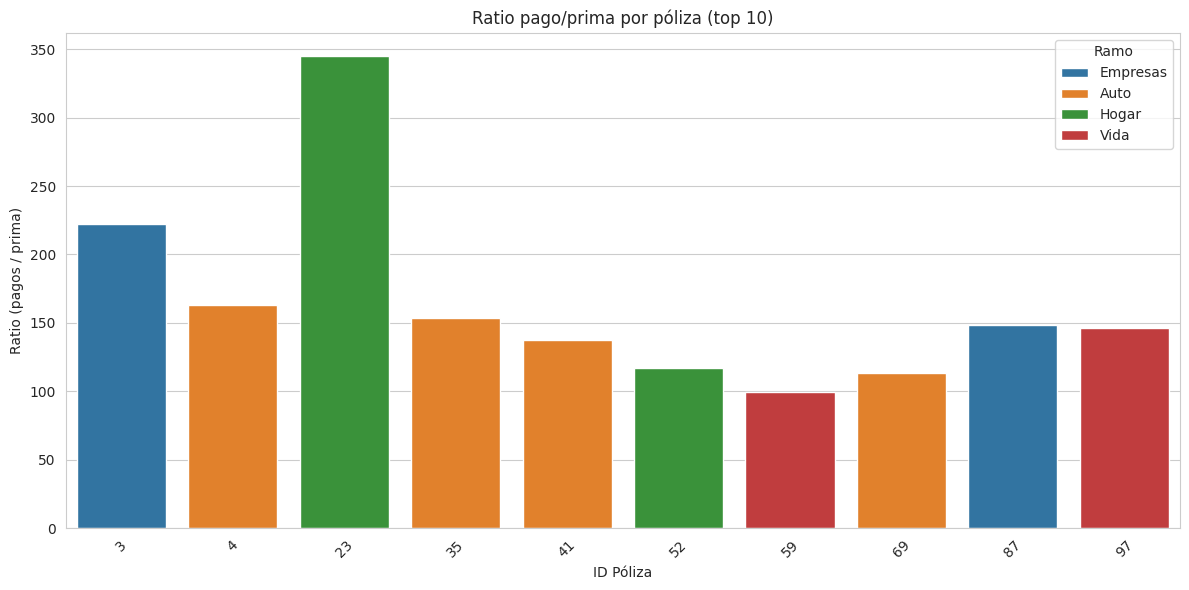

In [18]:
query4 = '''
SELECT
    p.id_poliza,
    p.ramo,
    p.asegurado,
    p.prima,
    COALESCE(SUM(pg.monto_pago), 0) AS total_pagado,
    ROUND(COALESCE(SUM(pg.monto_pago), 0) / p.prima, 2) AS ratio_pago_prima
FROM polizas p
LEFT JOIN siniestros s ON p.id_poliza = s.id_poliza
LEFT JOIN pagos pg ON s.id_siniestro = pg.id_siniestro
GROUP BY p.id_poliza
HAVING total_pagado > 0
ORDER BY ratio_pago_prima DESC
LIMIT 10;
'''

df_top = pd.read_sql_query(query4, conn)
print("🔥 Top 10 pólizas con mayor ratio pago/prima:")
print(df_top)

# Gráfico de barras
plt.figure()
sns.barplot(data=df_top, x='id_poliza', y='ratio_pago_prima', hue='ramo', dodge=False)
plt.title('Ratio pago/prima por póliza (top 10)')
plt.ylabel('Ratio (pagos / prima)')
plt.xlabel('ID Póliza')
plt.xticks(rotation=45)
plt.legend(title='Ramo')
plt.tight_layout()
plt.show()

In [19]:
## ✅ Conclusiones del proyecto

#- Se ha diseñado una base de datos relacional funcional que refleja la operatoria de una compañía de seguros.
#- Las consultas SQL permiten extraer indicadores de riesgo clave:
#  - Siniestralidad por ramo (loss ratio).
#  - Estimación de IBNR mediante identificación de siniestros no reportados.
#  - Antigüedad de siniestros abiertos.
#  - Pólizas más problemáticas (alto ratio pago/prima).
#  - La combinación de SQL con Python (pandas y matplotlib) facilita la visualización y comunicación de resultados.

#Próximos pasos: Incorporar métodos de reservas más sofisticados (Chain-Ladder, BF) directamente sobre los datos almacenados en SQL, integrando así los proyectos 1 y 3.